In [1]:
import pickle

import numpy as np
import pandas as pd

import dask
import dask.dataframe as dd
from dask.distributed import Client, LocalCluster

import rdkit.Chem.Descriptors as Descriptors
import rdkit.Chem as Chem
from rdkit.Chem import PandasTools

from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*') # Disable the RDKit C++ Warning

from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import matthews_corrcoef, roc_auc_score, r2_score, mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
drugbank = PandasTools.LoadSDF('../DrugBank/structures.sdf')
print('Total number of compounds in DrugBank:', len(drugbank))

Total number of compounds in DrugBank: 11915


In [3]:
cluster = LocalCluster(threads_per_worker=1, n_workers=32, memory_limit='64GB')
client = Client(cluster)

In [4]:
vocab_data = dd.read_parquet('./B3DB/B3DB_classification_clean.parquet').compute()
with open('./B3DB/B3DB_classification_clean.parquet.vocab', 'rb') as f:
    vocab, mol_dict = pickle.load(f)

In [5]:
pubchem_data = dd.read_parquet('../../NIH-Pubchem-2024-02-12/CID-InChI-Key-Cliques.parquet')
pubchem_data = pubchem_data.dropna()#.persist() # Drop any molecules with NaNs

print('Total number of molecules in PubChem after initial processing:', len(pubchem_data))

Total number of molecules in PubChem after initial processing: 112194965


In [6]:
X = vocab_data[vocab]
y = (vocab_data['BBB+/BBB-'] == 'BBB+')
X_logbb = vocab_data.dropna(subset=['logBB'])[vocab]
y_logbb = vocab_data.dropna(subset=['logBB'])['logBB']

In [7]:
precision_pos = np.zeros((10, 5))
recall_pos = np.zeros((10, 5))
precision_neg = np.zeros((10, 5))
recall_neg = np.zeros((10, 5))

for i in range(10):
    # Setting the random state here to i gives us reproducibility
    # but ensures we get a new random set of kfold indices each time
    kf = KFold(n_splits=5, shuffle=True, random_state=i)
    for j, (train_index, test_index) in enumerate(kf.split(X)):
        print('Training Repeat {} Fold {}'.format(i, j))
        X_train, X_test = X.loc[train_index], X.loc[test_index]
        y_train, y_test = y.loc[train_index], y.loc[test_index]

        y_train = y_train[np.any(X_train > 0, axis=1)]
        X_train = X_train[np.any(X_train > 0, axis=1)]

        clf = RandomForestClassifier(n_estimators=128, random_state=42)
        clf.fit(X_train, y_train)

        pred_test = (clf.predict_proba(X_test)[:, 1] == 1.0).astype(np.float32)
        precision_pos[i, j] = np.sum(pred_test * y_test) / np.sum(pred_test)
        recall_pos[i, j] = np.sum(pred_test * y_test) / np.sum(y_test)

        pred_test = (clf.predict_proba(X_test)[:, 1] > 0.05).astype(np.float32)
        precision_neg[i, j] = np.sum((1 - pred_test) * (1 - y_test)) / np.sum(1 - pred_test)
        recall_neg[i, j] = np.sum((1 - pred_test) * (1 - y_test)) / np.sum(1 - y_test)

print("Repeated cross validation precision when screening for BBBP+ (1.0 threshold)", np.mean(precision_pos))
print("Repeated cross validation recall (sensitivity) when screening for BBBP+ (1.0 threshold)", np.mean(recall_pos))

print("Repeated cross validation precision when screening for BBBP- (0.05 threshold)", np.mean(precision_neg))
print("Repeated cross validation recall (sensitivity) when screening for BBBP- (0.05 threshold)", np.mean(recall_neg))

Training Repeat 0 Fold 0
Training Repeat 0 Fold 1
Training Repeat 0 Fold 2
Training Repeat 0 Fold 3
Training Repeat 0 Fold 4
Training Repeat 1 Fold 0
Training Repeat 1 Fold 1
Training Repeat 1 Fold 2
Training Repeat 1 Fold 3
Training Repeat 1 Fold 4
Training Repeat 2 Fold 0
Training Repeat 2 Fold 1
Training Repeat 2 Fold 2
Training Repeat 2 Fold 3
Training Repeat 2 Fold 4
Training Repeat 3 Fold 0
Training Repeat 3 Fold 1
Training Repeat 3 Fold 2
Training Repeat 3 Fold 3
Training Repeat 3 Fold 4
Training Repeat 4 Fold 0
Training Repeat 4 Fold 1
Training Repeat 4 Fold 2
Training Repeat 4 Fold 3
Training Repeat 4 Fold 4
Training Repeat 5 Fold 0
Training Repeat 5 Fold 1
Training Repeat 5 Fold 2
Training Repeat 5 Fold 3
Training Repeat 5 Fold 4
Training Repeat 6 Fold 0
Training Repeat 6 Fold 1
Training Repeat 6 Fold 2
Training Repeat 6 Fold 3
Training Repeat 6 Fold 4
Training Repeat 7 Fold 0
Training Repeat 7 Fold 1
Training Repeat 7 Fold 2
Training Repeat 7 Fold 3
Training Repeat 7 Fold 4


In [8]:
rmse = np.zeros((10, 5))
r2 = np.zeros((10, 5))

for i in range(10):
    # Setting the random state here to i gives us reproducibility
    # but ensures we get a new random set of kfold indices each time
    kf = KFold(n_splits=5, shuffle=True, random_state=i)
    for j, (train_index, test_index) in enumerate(kf.split(X_logbb)):
        print('Training Repeat {} Fold {}'.format(i, j))
        X_train, X_test = X_logbb.loc[train_index], X_logbb.loc[test_index]
        y_train, y_test = y_logbb.loc[train_index], y_logbb.loc[test_index]

        y_train = y_train[np.any(X_train > 0, axis=1)]
        X_train = X_train[np.any(X_train > 0, axis=1)]

        clf_logbb = RandomForestRegressor(n_estimators=128, random_state=42)
        clf_logbb.fit(X_train, y_train)

        pred_test = clf_logbb.predict(X_test)

        rmse[i, j] = np.sqrt(np.mean((pred_test - y_test)**2))
        r2[i, j] = r2_score(y_test, pred_test)
print("Repeated cross validation RMSE", np.mean(rmse))
print("Repeated cross validation R2", np.mean(r2))
print("logBB Standard Deviation", np.std(y_logbb))

Training Repeat 0 Fold 0
Training Repeat 0 Fold 1
Training Repeat 0 Fold 2
Training Repeat 0 Fold 3
Training Repeat 0 Fold 4
Training Repeat 1 Fold 0
Training Repeat 1 Fold 1
Training Repeat 1 Fold 2
Training Repeat 1 Fold 3
Training Repeat 1 Fold 4
Training Repeat 2 Fold 0
Training Repeat 2 Fold 1
Training Repeat 2 Fold 2
Training Repeat 2 Fold 3
Training Repeat 2 Fold 4
Training Repeat 3 Fold 0
Training Repeat 3 Fold 1
Training Repeat 3 Fold 2
Training Repeat 3 Fold 3
Training Repeat 3 Fold 4
Training Repeat 4 Fold 0
Training Repeat 4 Fold 1
Training Repeat 4 Fold 2
Training Repeat 4 Fold 3
Training Repeat 4 Fold 4
Training Repeat 5 Fold 0
Training Repeat 5 Fold 1
Training Repeat 5 Fold 2
Training Repeat 5 Fold 3
Training Repeat 5 Fold 4
Training Repeat 6 Fold 0
Training Repeat 6 Fold 1
Training Repeat 6 Fold 2
Training Repeat 6 Fold 3
Training Repeat 6 Fold 4
Training Repeat 7 Fold 0
Training Repeat 7 Fold 1
Training Repeat 7 Fold 2
Training Repeat 7 Fold 3
Training Repeat 7 Fold 4


In [9]:
clf = RandomForestClassifier(n_estimators=128, random_state=42)
clf.fit(X, y)
clf_logbb = RandomForestRegressor(n_estimators=128, random_state=42)
clf_logbb.fit(X_logbb, y_logbb)

RandomForestRegressor(n_estimators=128, random_state=42)

In [10]:
def predict_forest(partition, clf, rgr, vocab):
    X = partition[vocab]
    output = partition.assign(**{
        'BBB+':clf.predict_proba(X)[:, 1],
        'logBB':rgr.predict(X)
    })
    return output

pred_forest = pubchem_data.map_partitions(predict_forest, clf=clf, rgr=clf_logbb, vocab=vocab)#.persist()
#print(pred_forest.head())

trial_pos = pred_forest[pred_forest['BBB+'] == 1.0]
trial_neg = pred_forest[pred_forest['BBB+'] <= 0.05]

trial_pos.compute().to_csv('initial_positive_pubchem.csv')
trial_neg.compute().to_csv('initial_negative_pubchem.csv')

print('BBBP +/- candidates:', len(trial_pos), len(trial_neg))

BBBP +/- candidates: 197884 96949


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(array([-0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(-0.2, 0, '−0.2'),
  Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4000000000000001, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0000000000000002, 0, '1.0'),
  Text(1.2000000000000002, 0, '1.2')])

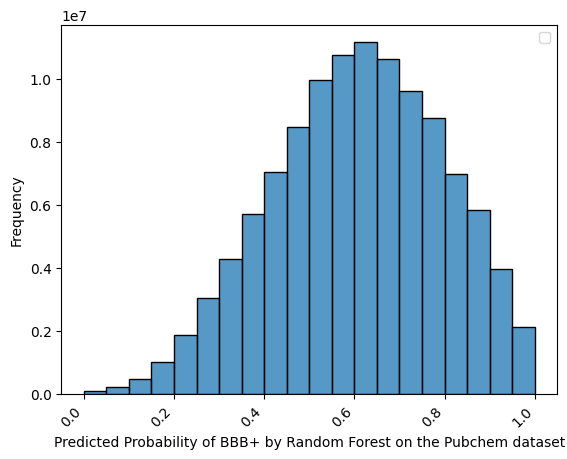

In [11]:
sns.histplot(pred_forest['BBB+'].compute(), bins=20)
plt.ylabel('Frequency')
plt.xlabel('Predicted Probability of BBB+ by Random Forest on the Pubchem dataset')
plt.legend()
plt.xticks(rotation=45, ha='right')

In [12]:
def filter_molwt(partition):
    return partition[partition['MolWt'] <= 500]

trial_pos = trial_pos.map_partitions(filter_molwt).persist()
trial_neg = trial_neg.map_partitions(filter_molwt).persist()
print('BBBP +/- candidates after filtering by MolWt <= 500:', len(trial_pos), len(trial_neg))

BBBP +/- candidates after filtering by MolWt <= 500: 192464 35037


In [13]:
def filter_logp(partition):
    out = partition[partition['LogP'] >= 2]
    out = out[out['LogP'] <= 10]
    return out

trial_pos = trial_pos.map_partitions(filter_logp).persist()
trial_neg = trial_neg.map_partitions(filter_logp).persist()
print('BBBP +/- candidates after filtering by 2 <= LogP <= 10:', len(trial_pos), len(trial_neg))

BBBP +/- candidates after filtering by 2 <= LogP <= 10: 115003 10741


In [14]:
def filter_inchiid(data, filter_data):
    mask = ~data['InChIID'].isin(filter_data)
    return data[mask]

def filter_inchikey(data, filter_data):
    # Note: We only care about the first section of the Inchi Key
    # See: https://www.inchi-trust.org/
    pubchem_key = data['InChIKey'].apply(lambda x: x.split('-')[0])
    filter_key = filter_data.apply(lambda x: x.split('-')[0])

    mask = ~pubchem_key.isin(filter_key)
    return data[mask]

In [15]:
trial_pos = trial_pos.map_partitions(filter_inchiid, filter_data=vocab_data['Inchi']).persist()
trial_neg = trial_neg.map_partitions(filter_inchiid, filter_data=vocab_data['Inchi']).persist()

print('BBBP +/- candidates after filtering duplicates from vocab data (B3DB):', len(trial_pos), len(trial_neg))

BBBP +/- candidates after filtering duplicates from vocab data (B3DB): 114263 10632


In [16]:
trial_pos = trial_pos.map_partitions(filter_inchiid, filter_data=drugbank['INCHI_IDENTIFIER']).persist()
trial_neg = trial_neg.map_partitions(filter_inchiid, filter_data=drugbank['INCHI_IDENTIFIER']).persist()

print('BBBP +/- candidates after filtering duplicates from DrugBank data with InchI Identifier:', len(trial_pos), len(trial_neg))

trial_pos = trial_pos.map_partitions(filter_inchikey, filter_data=drugbank['INCHI_KEY']).persist()
trial_neg = trial_neg.map_partitions(filter_inchikey, filter_data=drugbank['INCHI_KEY']).persist()

print('BBBP +/- candidates after filtering duplicates from DrugBank data with InchI Key:', len(trial_pos), len(trial_neg))

BBBP +/- candidates after filtering duplicates from DrugBank data with InchI Identifier: 114216 10605
BBBP +/- candidates after filtering duplicates from DrugBank data with InchI Key: 112598 9117


In [17]:
# Filter out all molecules which aren't represented by our cliques descriptor
trial_pos = trial_pos[trial_pos[vocab].sum(axis=1) > 0].persist()
trial_neg = trial_neg[trial_neg[vocab].sum(axis=1) > 0].persist()

print('BBBP +/- candidates in PubChem after filtering molecules which can\'t be represented by our vocab:', len(trial_pos), len(trial_neg))

BBBP +/- candidates in PubChem after filtering molecules which can't be represented by our vocab: 100840 9117


In [18]:
from cliques.cliques import Vocabulary

def contains_unknown_cliques(partition, vocab):
    RDLogger.DisableLog('rdApp.*') # Disable the RDKit C++ Warning
    known = []
    for idx, row in partition.iterrows():
        mol_vocab = Vocabulary([row['SMILES']])
        if mol_vocab.issubset(vocab):
            known += [True]
        else:
            known += [False]
    return partition[pd.Series(known, index=partition.index)]

trial_pos = trial_pos.repartition(npartitions=4)
trial_neg = trial_neg.repartition(npartitions=4)
trial_pos = trial_pos.map_partitions(contains_unknown_cliques, vocab=vocab, meta=trial_pos).persist()
trial_neg = trial_neg.map_partitions(contains_unknown_cliques, vocab=vocab, meta=trial_neg).persist()
print('BBBP +/- candidates after filtering molecules which have unknown cliques:', len(trial_pos), len(trial_neg))

BBBP +/- candidates after filtering molecules which have unknown cliques: 77086 8025


In [19]:
print('BBBP+/- candidates before removing molecules which can\'t be uniquely represented by cliques:', len(trial_pos), len(trial_neg))

trial_pos = trial_pos.compute().drop_duplicates(subset=vocab, keep=False)
trial_neg = trial_neg.compute().drop_duplicates(subset=vocab, keep=False)

print('BBBP+/- candidates after removing molecules which can\'t be uniquely represented by cliques:', len(trial_pos), len(trial_neg))

BBBP+/- candidates before removing molecules which can't be uniquely represented by cliques: 77086 8025
BBBP+/- candidates after removing molecules which can't be uniquely represented by cliques: 4209 964


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(array([  0., 100., 200., 300., 400., 500., 600.]),
 [Text(0.0, 0, '0'),
  Text(100.0, 0, '100'),
  Text(200.0, 0, '200'),
  Text(300.0, 0, '300'),
  Text(400.0, 0, '400'),
  Text(500.0, 0, '500'),
  Text(600.0, 0, '600')])

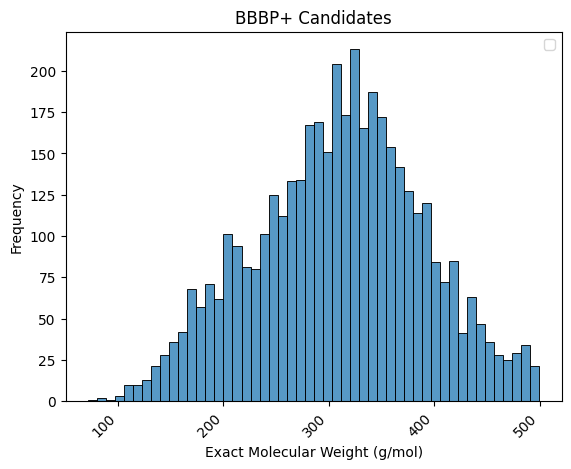

In [20]:
sns.histplot(trial_pos['MolWt'], bins=50)
plt.title('BBBP+ Candidates')
plt.ylabel('Frequency')
plt.xlabel('Exact Molecular Weight (g/mol)')
plt.legend()
plt.xticks(rotation=45, ha='right')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(array([100., 150., 200., 250., 300., 350., 400., 450., 500., 550.]),
 [Text(100.0, 0, '100'),
  Text(150.0, 0, '150'),
  Text(200.0, 0, '200'),
  Text(250.0, 0, '250'),
  Text(300.0, 0, '300'),
  Text(350.0, 0, '350'),
  Text(400.0, 0, '400'),
  Text(450.0, 0, '450'),
  Text(500.0, 0, '500'),
  Text(550.0, 0, '550')])

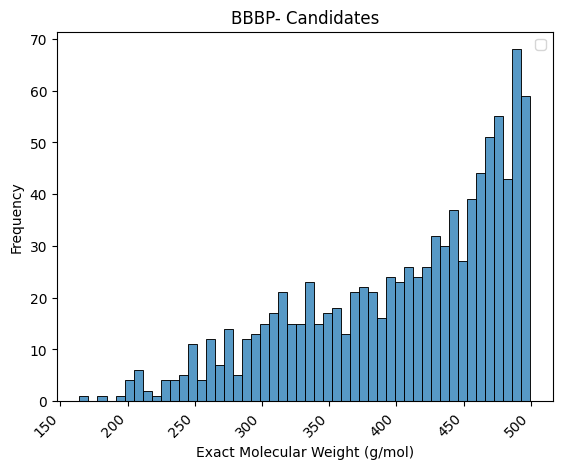

In [21]:
sns.histplot(trial_neg['MolWt'], bins=50)
plt.title('BBBP- Candidates')
plt.ylabel('Frequency')
plt.xlabel('Exact Molecular Weight (g/mol)')
plt.legend()
plt.xticks(rotation=45, ha='right')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.]),
 [Text(1.0, 0, '1'),
  Text(2.0, 0, '2'),
  Text(3.0, 0, '3'),
  Text(4.0, 0, '4'),
  Text(5.0, 0, '5'),
  Text(6.0, 0, '6'),
  Text(7.0, 0, '7'),
  Text(8.0, 0, '8'),
  Text(9.0, 0, '9'),
  Text(10.0, 0, '10'),
  Text(11.0, 0, '11')])

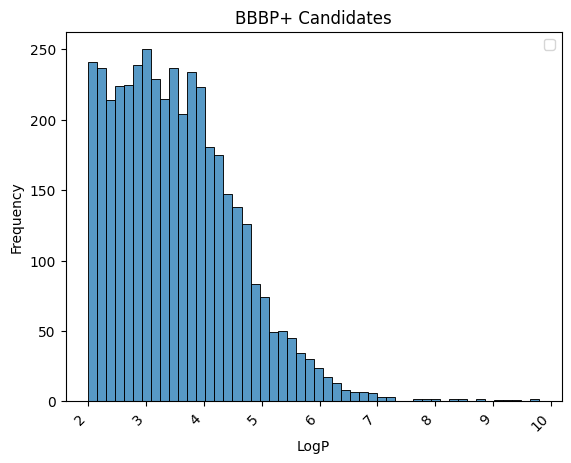

In [22]:
sns.histplot(trial_pos['LogP'], bins=50)
plt.title('BBBP+ Candidates')
plt.ylabel('Frequency')
plt.xlabel('LogP')
plt.legend()
plt.xticks(rotation=45, ha='right')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.]),
 [Text(1.0, 0, '1'),
  Text(2.0, 0, '2'),
  Text(3.0, 0, '3'),
  Text(4.0, 0, '4'),
  Text(5.0, 0, '5'),
  Text(6.0, 0, '6'),
  Text(7.0, 0, '7'),
  Text(8.0, 0, '8'),
  Text(9.0, 0, '9'),
  Text(10.0, 0, '10'),
  Text(11.0, 0, '11')])

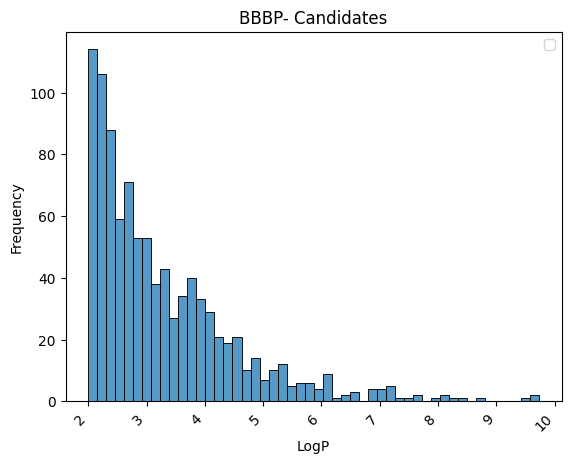

In [23]:
sns.histplot(trial_neg['LogP'], bins=50)
plt.title('BBBP- Candidates')
plt.ylabel('Frequency')
plt.xlabel('LogP')
plt.legend()
plt.xticks(rotation=45, ha='right')

In [24]:
# The Azetidine group seems to cause gromacs to crash as it seems to be parameterised poorly by charmmgui
trial_pos = trial_pos[trial_pos['C1CNC1'] == 0]
trial_neg = trial_neg[trial_neg['C1CNC1'] == 0]

trial_pos = trial_pos.sort_values(by='logBB')
trial_pos = trial_pos.iloc[-min(30, len(trial_pos)):]
print(trial_pos.head())
trial_pos.to_csv('bbbp_positive_pubchem.csv')

trial_neg = trial_neg.sort_values(by='logBB')
trial_neg = trial_neg.iloc[:min(30, len(trial_neg))]
print(trial_neg.head())
trial_neg.to_csv('bbbp_negative_pubchem.csv')

              idx                                            InChIID  \
86325    24841531  InChI=1S/C17H20N2OS.ClH/c1-18(2)12-7-13-19-14-...   
16344    10313562  InChI=1S/C18H22N2OS/c1-3-19(4-2)13-14-20-15-9-...   
287793  142026102  InChI=1S/C22H27ClN2/c1-16-8-9-18(13-20(16)23)2...   
185098   66655649  InChI=1S/C20H21Cl2NO2/c1-23-9-7-20(8-10-23)13-...   
254593    3066532  InChI=1S/C21H27N3S/c1-3-22-12-14-23(15-13-22)1...   

                           InChIKey       MolWt    LogP  \
86325   KRRSKLLEVCBCAR-UHFFFAOYSA-N  336.888000  3.0994   
16344   FHJXMDBVMWVIIL-UHFFFAOYSA-N  314.454010  3.0677   
287793  NKRQKFVONMTUDF-YDNXMHBPSA-N  354.924988  5.2350   
185098  PVBHOMKIYDPNIE-UHFFFAOYSA-N  378.299011  4.6384   
254593  NJMPBWJSNSMVTD-UHFFFAOYSA-N  353.535004  3.7364   

                                                   SMILES  C1CCSNC1  C1CNOC1  \
86325           CN(C)CCCN1C2=CC=CC=C2S(=O)C2=CC=CC=C21.Cl       0.0      0.0   
16344             CCN(CC)CCN1C2=CC=CC=C2S(=O)C2=CC=C